# 1. Imports and setup.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Clustering & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage

# Association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Plot style
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

print('All packages imported successfully')

All packages imported successfully


# 2. Data Loading.

In [2]:
from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original
print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Raw dataset: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 3. Visualizing Raw Data.

# 4. Data Cleaning and Preprocessing.

In [5]:
# 1. Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. UK-only
df = df[df['Country'] == 'United Kingdom']

# 3. Positive quantities only
df = df[df['Quantity'] > 0]

# 4. Non-null, non-empty descriptions
df = df[~(df['Description'].isna() | (df['Description'].str.strip() == ''))]

# 5. Positive unit prices only
df = df[df['UnitPrice'] > 0]

# 6. Parse dates and derived columns
df['InvoiceDate']  = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month']        = df['InvoiceDate'].dt.month
df['TotalPrice']   = df['Quantity'] * df['UnitPrice']

print(f'Clean dataset: {df.shape[0]:,} rows')
print(f'Date range:    {df["InvoiceDate"].min().date()} — {df["InvoiceDate"].max().date()}')
print(f'Invoices: {df["InvoiceNo"].nunique():,}\n  '
      f'Customers (with ID): {df["CustomerID"].nunique():,}\n  '
      f'Unique products: {df["StockCode"].nunique():,}')

Clean dataset: 485,123 rows
Date range:    2010-12-01 — 2011-12-09

Invoices: 18,019
  Customers (with ID): 3,920
  Unique products: 3,916


# 5. Association Rule Mining — Apriori vs FP-Growth
Both algorithms are run on the same basket matrix with identical thresholds, allowing a direct comparison of runtime and rule output.
**Threshold justification:**
- `min_support = 0.01` (1% of invoices). At 0.02 only 5 rules survived. At 0.01, 177 rules emerged across three distinct product families. At 0.005, >2,000 rules with many trivial patterns.
- `min_confidence = 0.80`: Each rule predicts its consequent in at least 80% of qualifying transactions.

In [6]:
# Build basket matrix (one row per invoice)
baskets = (df.groupby('InvoiceNo')['Description']
             .apply(list)
             .reset_index(name='items'))
transactions = baskets['items'].tolist()

te = TransactionEncoder()
# Cast columns to plain str — avoids mlxtend/numpy string-type incompatibility
basket_matrix = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=[str(c) for c in te.columns_]
)
print(f'Basket matrix: {basket_matrix.shape[0]:,} invoices × {basket_matrix.shape[1]:,} products')

Basket matrix: 18,019 invoices × 4,007 products


In [8]:
# Apriori
t0 = time.perf_counter()
fi_apriori = apriori(basket_matrix, min_support=0.01, use_colnames=True)
ir_apriori = association_rules(fi_apriori, metric='confidence', min_threshold=0.80)
t_apriori  = time.perf_counter() - t0

# FP-Growth
t0 = time.perf_counter()
fi_fp = fpgrowth(basket_matrix, min_support=0.01, use_colnames=True)
ir_fp = association_rules(fi_fp, metric='confidence', min_threshold=0.80)
t_fp  = time.perf_counter() - t0

# ── Comparison table
comparison = pd.DataFrame({
    'Algorithm':      ['Apriori', 'FP-Growth'],
    'Frequent itemsets': [len(fi_apriori), len(fi_fp)],
    'Rules generated':   [len(ir_apriori), len(ir_fp)],
    'Runtime (s)':       [round(t_apriori, 3), round(t_fp, 3)],
    'Speedup':           ['1.0×', f'{t_apriori/t_fp:.1f}×'],
})
print('=== Algorithm Comparison ===')
print(comparison.to_string(index=False))
print(f'\nRule sets identical: {len(ir_apriori) == len(ir_fp)}')

=== Algorithm Comparison ===
Algorithm  Frequent itemsets  Rules generated  Runtime (s) Speedup
  Apriori               2156              177      152.099    1.0×
FP-Growth               2156              177        8.726   17.4×

Rule sets identical: True


In [9]:
# Top rules by lift
item_rules = ir_apriori.copy()   # use Apriori output for remainder
item_rules.sort_values('lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

,antecedents,consequents,support,confidence,lift
120,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",0.010933,0.856522,74.558769
115,"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",frozenset({HERB MARKER THYME}),0.010933,0.951691,74.558769
110,"frozenset({HERB MARKER MINT, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010600,0.955000,74.494134
113,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.010600,0.826840,74.494134
107,frozenset({HERB MARKER PARSLEY}),"frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.010433,0.824561,74.288860
104,"frozenset({HERB MARKER MINT, HERB MARKER THYME})",frozenset({HERB MARKER PARSLEY}),0.010433,0.940000,74.288860
117,"frozenset({HERB MARKER PARSLEY, HERB MARKER TH...",frozenset({HERB MARKER ROSEMARY}),0.010933,0.951691,74.236004
118,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER PARSLEY, HERB MARKER TH...",0.010933,0.852814,74.236004
94,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",0.010711,0.835498,74.161751
93,"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010711,0.950739,74.161751


In [10]:
# clustering rules into product families.
def has_kw(itemset, kw):
    return any(kw.upper() in str(i).upper() for i in itemset)

herb_r   = item_rules[item_rules['antecedents'].apply(lambda x: has_kw(x,'HERB'))]
teacup_r = item_rules[item_rules['antecedents'].apply(
    lambda x: has_kw(x,'REGENCY') or has_kw(x,'TEACUP'))]
jumbo_r  = item_rules[item_rules['antecedents'].apply(lambda x: has_kw(x,'JUMBO'))]
other_r  = item_rules.drop(index=herb_r.index.union(teacup_r.index).union(jumbo_r.index))

families = pd.DataFrame({
    'Product Family': ['Herb Markers','Regency Teacup Set','Jumbo Bag Collection','Other'],
    'Rules':   [len(herb_r), len(teacup_r), len(jumbo_r), len(other_r)],
    'Avg Lift': [herb_r['lift'].mean(), teacup_r['lift'].mean(),
                  jumbo_r['lift'].mean(), other_r['lift'].mean() if len(other_r) else 0],
    'Avg Confidence': [herb_r['confidence'].mean(), teacup_r['confidence'].mean(),
                        jumbo_r['confidence'].mean(), other_r['confidence'].mean() if len(other_r) else 0],
}).round(3)
print(families.to_string(index=False))

      Product Family  Rules  Avg Lift  Avg Confidence
        Herb Markers     81    71.235           0.879
  Regency Teacup Set     20    26.752           0.876
Jumbo Bag Collection     38    10.173           0.837
               Other     40    21.964           0.853


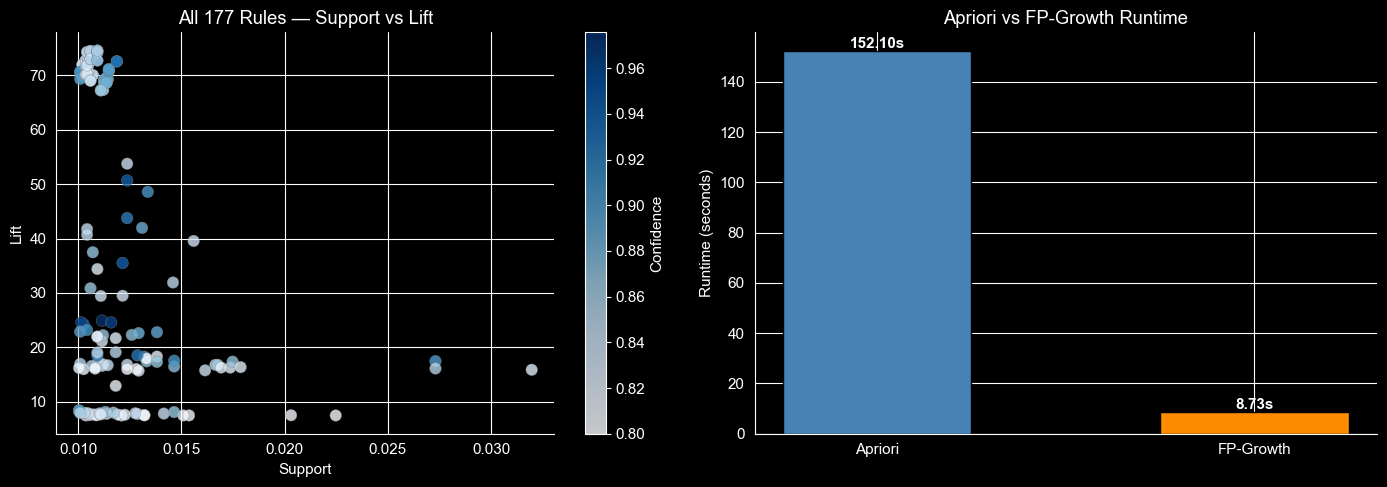

In [11]:
#figures showing findings from running the two algorithms.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Support vs Lift, colored by confidence
sc = axes[0].scatter(item_rules['support'], item_rules['lift'],
                     c=item_rules['confidence'], cmap='Blues',
                     alpha=0.8, edgecolors='grey', linewidths=0.3, s=70)
plt.colorbar(sc, ax=axes[0], label='Confidence')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Lift')
axes[0].set_title(f'All {len(item_rules)} Rules — Support vs Lift')

# Right: Apriori vs FP-Growth runtime bar
axes[1].bar(['Apriori', 'FP-Growth'], [t_apriori, t_fp],
            color=['steelblue', 'darkorange'], edgecolor='black', width=0.5)
axes[1].set_ylabel('Runtime (seconds)')
axes[1].set_title('Apriori vs FP-Growth Runtime')
for i, v in enumerate([t_apriori, t_fp]):
    axes[1].text(i, v + 0.02, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# effect of threshold choice; justifying the threshold choice for both algorithms.
frequent_itemsets2 = apriori(basket_matrix, min_support=0.02, use_colnames=True)
item_rules2 = association_rules(frequent_itemsets2, metric='confidence', min_threshold=0.80)
print(f'At min_support=0.02: {len(item_rules2)} rules')
print(f'At min_support=0.01: {len(item_rules)} rules')
print('\nAll rules at min_support=0.02:')
item_rules2.sort_values('lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']
]

At min_support=0.02: 5 rules
At min_support=0.01: 177 rules

All rules at min_support=0.02:


,antecedents,consequents,support,confidence,lift
1,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
2,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
0,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
3,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO SHOP...",frozenset({JUMBO BAG RED RETROSPOT}),0.020312,0.806167,7.507147
4,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO STOR...",frozenset({JUMBO BAG RED RETROSPOT}),0.022476,0.801980,7.468156


# 6. RFM Feature Engineering
RFM reduces each customer to three interpretable behavioral dimensions:
- **Recency** — days since last purchase (lower = more recent)
- **Frequency** — number of distinct invoices
- **Monetary** — total spend in GBP

Only rows with a valid CustomerID are used for customer-level analysis.


In [13]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date (day after last transaction): {reference_date.date()}')

df_cust = df.dropna(subset=['CustomerID']).copy()
df_cust['CustomerID'] = df_cust['CustomerID'].astype(int)

rfm = df_cust.groupby('CustomerID').agg(
    Recency  = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency= ('InvoiceNo',   'nunique'),
    Monetary = ('TotalPrice',  'sum')
).reset_index()

print(f'Customers with complete RFM: {len(rfm):,}')
rfm.describe().round(2)

Reference date (day after last transaction): 2011-12-10
Customers with complete RFM: 3,920


,CustomerID,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00,3920.00
mean,15562.06,92.21,4.25,1864.39
std,1576.59,99.53,7.20,7482.82
min,12346.00,1.00,1.00,3.75
25%,14208.75,18.00,1.00,300.28
50%,15569.50,51.00,2.00,652.28
75%,16913.25,143.00,5.00,1576.58
max,18287.00,374.00,209.00,259657.30


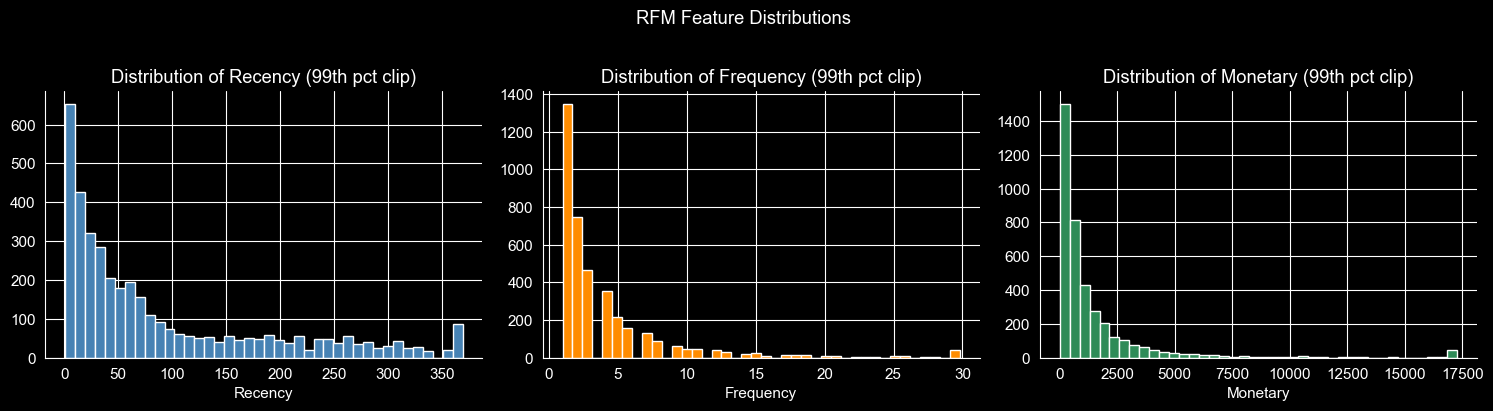

In [14]:
#figures displaying the distribution of RFM features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
    ['Recency','Frequency','Monetary'],
    ['steelblue','darkorange','seagreen']):
    rfm[col].clip(upper=rfm[col].quantile(0.99)).hist(bins=40, color=color, ax=ax)
    ax.set_title(f'Distribution of {col} (99th pct clip)')
    ax.set_xlabel(col)
plt.suptitle('RFM Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Standardizing RFM features.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
print('StandardScaler applied — mean ~0, std ~1 per feature')
pd.DataFrame(rfm_scaled, columns=['R_scaled','F_scaled','M_scaled']).describe().round(3)

StandardScaler applied — mean ~0, std ~1 per feature


,R_scaled,F_scaled,M_scaled
count,3920.000,3920.000,3920.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-0.916,-0.451,-0.249
25%,-0.746,-0.451,-0.209
50%,-0.414,-0.312,-0.162
75%,0.510,0.105,-0.038
max,2.831,28.445,34.456


# 7. Clustering — K-Means vs Hierarchical

Both algorithms are run at k=4 on standardised RFM features.
Three validation metrics are reported: **Silhouette** (higher = better separation),
**Davies-Bouldin** (lower = better), and **Calinski-Harabasz** (higher = better).

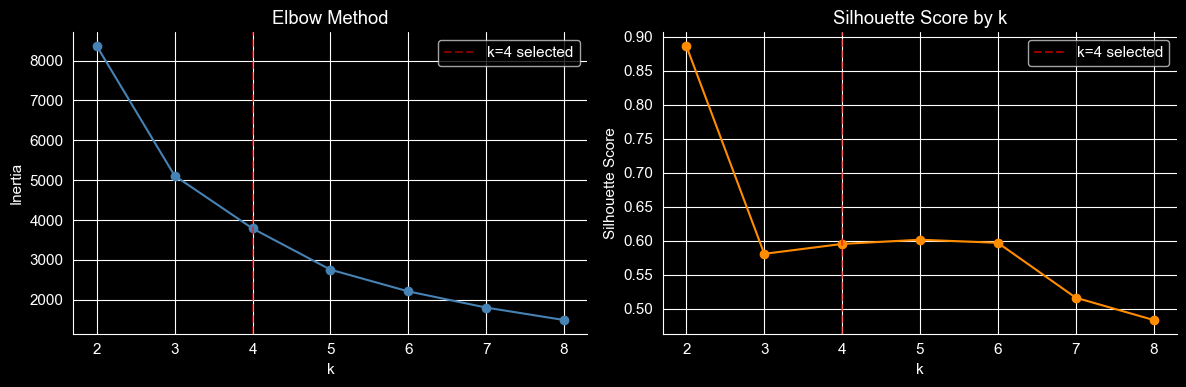

Best k by silhouette: 2  (score=0.886)


In [17]:
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].axvline(x=4, ls='--', color='red', alpha=0.5, label='k=4 selected')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 'o-', color='darkorange')
axes[1].axvline(x=4, ls='--', color='red', alpha=0.6, label='k=4 selected')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Best k by silhouette: {list(K_range)[silhouettes.index(max(silhouettes))]}  '
      f'(score={max(silhouettes):.3f})')

In [19]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km_final.fit_predict(rfm_scaled)

sil_km = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
db_km  = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])
ch_km  = calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster'])

cluster_profile = rfm.groupby('KMeans_Cluster').agg(
    Count         = ('CustomerID','count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(1)
cluster_profile['Revenue_%'] = (cluster_profile['Total_Revenue'] /
                                  cluster_profile['Total_Revenue'].sum() * 100).round(1)

print(f'K-Means (k=4) -- Silhouette: {sil_km:.3f} ; Davies-Bouldin: {db_km:.3f} ; Calinski-Harabasz: {ch_km:.0f}')
cluster_profile

K-Means (k=4) -- Silhouette: 0.595 ; Davies-Bouldin: 0.619 ; Calinski-Harabasz: 2745


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%
KMeans_Cluster,,,,,,
0,989,244.6,1.6,526.7,520941.3,7.1
1,52,12.2,43.8,31172.2,1620955.4,22.2
2,2876,41.4,4.4,1579.9,4543814.4,62.2
3,3,3.3,36.0,207560.2,622680.6,8.5


In [20]:
# Assign business labels based on RFM centroid values
profile = rfm.groupby('KMeans_Cluster').agg(
    R=('Recency', 'mean'), F=('Frequency', 'mean'), M=('Monetary', 'mean'))

names = {profile['M'].idxmax(): 'Champions'}
remaining = [c for c in profile.index if c not in names]
names[profile.loc[remaining, 'F'].idxmax()] = 'Loyal Regulars'
remaining = [c for c in profile.index if c not in names]
names[profile.loc[remaining, 'R'].idxmax()] = 'At-Risk / Lapsed'
remaining = [c for c in profile.index if c not in names]
names[remaining[0]] = 'New / Occasional'

rfm['Segment'] = rfm['KMeans_Cluster'].map(names)
print('Segment sizes:')
print(rfm['Segment'].value_counts())

Segment sizes:
Segment
New / Occasional    2876
At-Risk / Lapsed     989
Loyal Regulars        52
Champions              3
Name: count, dtype: int64


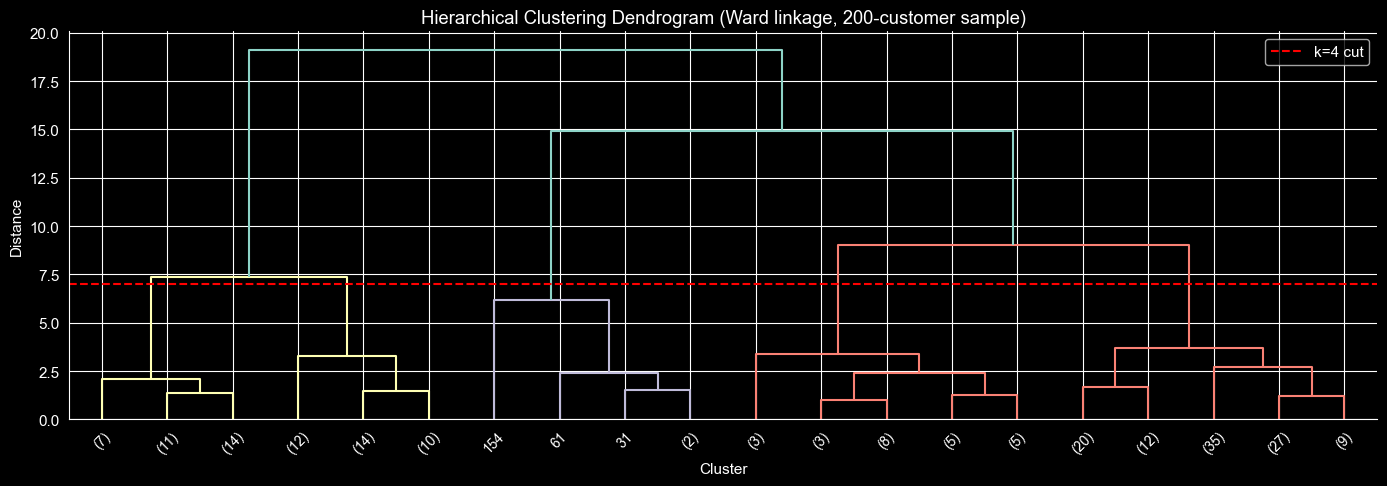

Hierarchical (k=4) -- Silhouette: 0.606 ; Davies-Bouldin: 0.653 ; Calinski-Harabasz: 2586


In [21]:
#  Hierarchical Clustering

# Dendrogram on a sample (full dataset too large to plot legibly)
sample_idx = np.random.RandomState(42).choice(len(rfm_scaled), size=200, replace=False)
Z = linkage(rfm_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 200-customer sample)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Distance')
ax.axhline(y=ax.get_ylim()[1]*0.35, ls='--', color='red', label='k=4 cut')
ax.legend()
plt.tight_layout(); plt.show()

# Fit full hierarchical model
hc = AgglomerativeClustering(n_clusters=4)
rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)

sil_hc = silhouette_score(rfm_scaled, rfm['HC_Cluster'])
db_hc  = davies_bouldin_score(rfm_scaled, rfm['HC_Cluster'])
ch_hc  = calinski_harabasz_score(rfm_scaled, rfm['HC_Cluster'])

print(f'Hierarchical (k=4) -- Silhouette: {sil_hc:.3f} ; Davies-Bouldin: {db_hc:.3f} ; Calinski-Harabasz: {ch_hc:.0f}')

In [23]:
# Side-by-side validation metric comparison
metrics = pd.DataFrame(
    {
        "Algorithm": [
            "K-Means (k=4)",
            "Hierarchical Ward (k=4)",
        ],
        "Silhouette (higher = better)": [
            round(sil_km, 3),
            round(sil_hc, 3),
        ],
        "Davies-Bouldin (lower = better)": [
            round(db_km, 3),
            round(db_hc, 3),
        ],
        "Calinski-Harabasz (higher = better)": [
            round(ch_km, 0),
            round(ch_hc, 0),
        ],
    }
)

print("=== Clustering Validation Metrics (k=4) ===")
print(metrics.to_string(index=False))
print("\nConclusion: K-Means outperforms Hierarchical Ward on all three internal metrics at k=4.")
print("K-Means is preferred: faster, higher silhouette, lower Davies-Bouldin, and higher Calinski-Harabasz.")

=== Clustering Validation Metrics (k=4) ===
              Algorithm  Silhouette (higher = better)  Davies-Bouldin (lower = better)  Calinski-Harabasz (higher = better)
          K-Means (k=4)                         0.595                            0.619                               2745.0
Hierarchical Ward (k=4)                         0.606                            0.653                               2586.0

Conclusion: K-Means outperforms Hierarchical Ward on all three internal metrics at k=4.
K-Means is preferred: faster, higher silhouette, lower Davies-Bouldin, and higher Calinski-Harabasz.


# 8. Anomaly Detection — DBSCAN and Local Outlier Factor

These two independent methods flag anomalous customers. Agreement between them validates the findings.

In [28]:
# 7. Anomaly Detection — DBSCAN and LOF
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
rfm['LOF_label'] = lof.fit_predict(rfm_scaled)
rfm['LOF_score'] = -lof.negative_outlier_factor_

n_dbscan_noise = (rfm['DBSCAN_Cluster'] == -1).sum()
n_lof_out = (rfm['LOF_label'] == -1).sum()

# Cross-validation: how many customers flagged by BOTH?
both_flagged = ((rfm['DBSCAN_Cluster'] == -1) & (rfm['LOF_label'] == -1)).sum()

print(f'DBSCAN noise points: {n_dbscan_noise} ({n_dbscan_noise / len(rfm) * 100:.1f}%)')
print(f'LOF anomalies:       {n_lof_out} ({n_lof_out / len(rfm) * 100:.1f}%)')
print(f'Flagged by both:     {both_flagged}')

anomalies = rfm[rfm['LOF_label'] == -1].sort_values('LOF_score', ascending=False)
print('\n=== Anomaly count by segment ===')
print(rfm.groupby('Segment')['LOF_label'].apply(lambda x: (x==-1).sum()))
print('\nTop ten (10) anomalous customers:')
anomalies[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'LOF_score', 'Segment']].head(10)

DBSCAN noise points: 52 (1.3%)
LOF anomalies:       196 (5.0%)
Flagged by both:     38

=== Anomaly count by segment ===
Segment
At-Risk / Lapsed    85
Champions            3
Loyal Regulars      23
New / Occasional    85
Name: LOF_label, dtype: int64

Top ten (10) anomalous customers:


,CustomerID,Recency,Frequency,Monetary,LOF_score,Segment
2820,16754,372,1,2002.40,6.433458,At-Risk / Lapsed
2,12748,1,209,33719.73,6.102733,Loyal Regulars
2307,16048,373,2,256.44,5.293406,At-Risk / Lapsed
3783,18102,1,60,259657.30,4.969851,Champions
1413,14813,370,2,155.43,4.292114,At-Risk / Lapsed
3598,17850,372,34,5391.21,4.034240,At-Risk / Lapsed
107,12967,358,2,1660.90,3.967778,At-Risk / Lapsed
2598,16446,1,2,168472.50,3.852541,Champions
3314,17450,8,46,194550.79,3.579474,Champions
1607,15098,182,3,39916.50,3.490667,At-Risk / Lapsed


In [29]:
# What the top anomalous customers bought.
top_ids = anomalies['CustomerID'].head(5).tolist()
print('Top transactions for most anomalous customers:')
(
    df_cust[df_cust['CustomerID'].isin(top_ids)]
    .sort_values('TotalPrice', ascending=False)
    [['CustomerID','InvoiceNo','InvoiceDate','Description','Quantity','UnitPrice','TotalPrice']]
    .head(15)
)

Top transactions for most anomalous customers:


,CustomerID,InvoiceNo,InvoiceDate,Description,Quantity,UnitPrice,TotalPrice
16438,18102,537659,2010-12-07 16:43:00,VINTAGE UNION JACK MEMOBOARD,600,6.38,3828.00
411231,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME NOTTING HILL,300,10.95,3285.00
411230,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME OXFORD STREET,300,10.95,3285.00
411229,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME COVENT GARDEN,300,10.95,3285.00
411232,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME LONDON BRIDGE,300,10.95,3285.00
411235,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME BAKER STREET,300,10.95,3285.00
411234,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME CAMDEN TOWN,300,10.95,3285.00
84319,18102,543378,2011-02-07 15:34:00,VINTAGE UNION JACK MEMOBOARD,504,6.38,3215.52
84323,18102,543379,2011-02-07 15:37:00,VINTAGE UNION JACK MEMOBOARD,504,6.38,3215.52
540061,18102,581457,2011-12-08 18:43:00,WALL ART KEEP CALM,698,4.15,2896.70


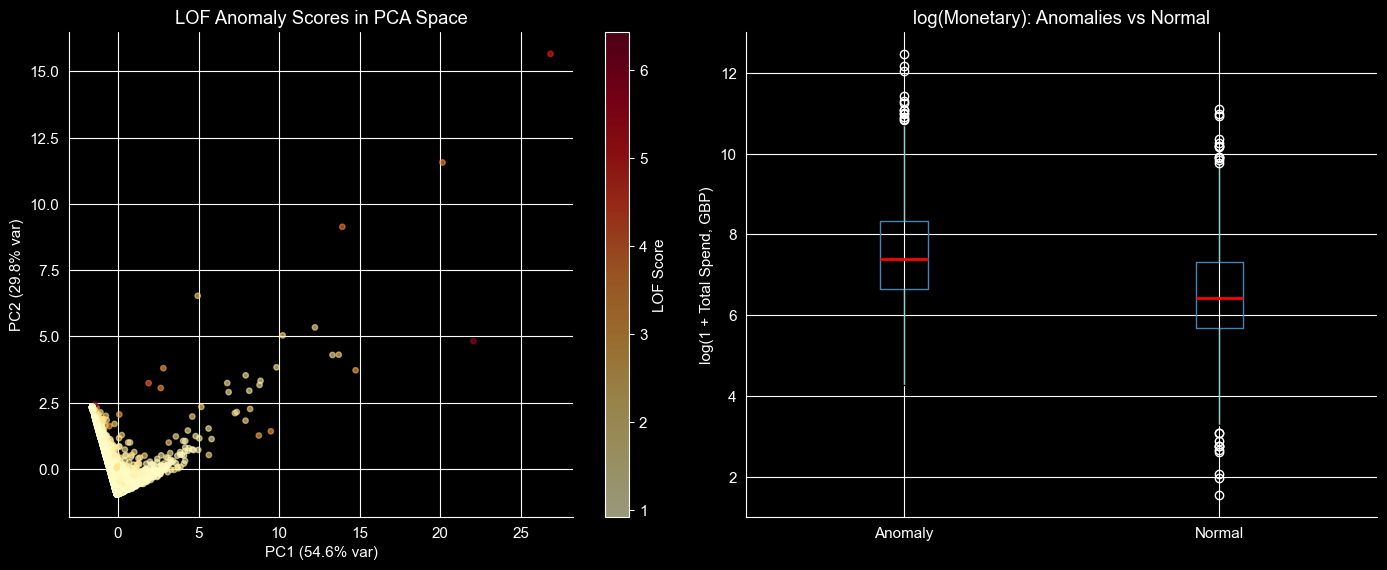

In [30]:
pca2 = PCA(n_components=2, random_state=42)
pca_coords = pca2.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: LOF scores in PCA space
sc = axes[0].scatter(pca_coords[:,0], pca_coords[:,1],
                     c=rfm['LOF_score'], cmap='YlOrRd', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0], label='LOF Score')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('LOF Anomaly Scores in PCA Space')

# Right: Monetary boxplot — anomalies vs normal
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Status'] = rfm['LOF_label'].map({1:'Normal', -1:'Anomaly'})
rfm.boxplot(column='Monetary_log', by='Status', ax=axes[1],
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='red', linewidth=2))
axes[1].set_title('log(Monetary): Anomalies vs Normal')
axes[1].set_xlabel(''); axes[1].set_ylabel('log(1 + Total Spend, GBP)')
plt.suptitle('')
plt.tight_layout(); plt.show()

# 8. PCA visualization by customer segment.

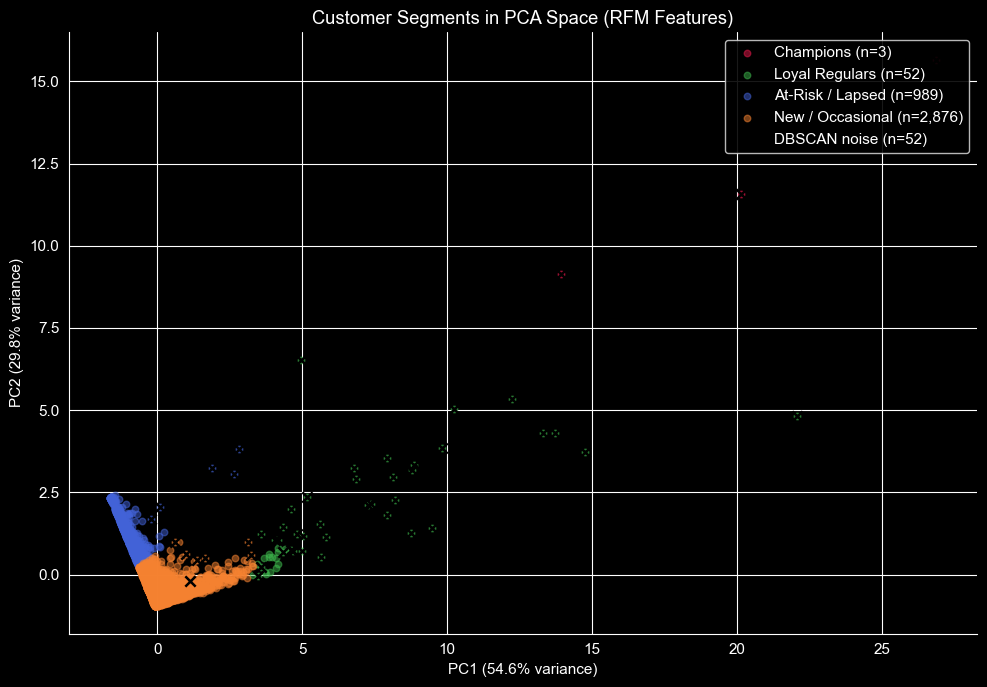

PC1 + PC2 total variance: 84.4%
Component loadings:
             PC1    PC2
Recency   -0.413  0.884
Frequency  0.670  0.131
Monetary   0.618  0.448


In [32]:
pca_df = pd.DataFrame(pca_coords, columns=['PC1','PC2'])
pca_df['Segment']      = rfm['Segment'].values
pca_df['DBSCAN_noise'] = (rfm['DBSCAN_Cluster'] == -1).values

palette = {'Champions':'#e6194b','Loyal Regulars':'#3cb44b',
           'At-Risk / Lapsed':'#4363d8','New / Occasional':'#f58231'}

fig, ax = plt.subplots(figsize=(10, 7))
for seg, color in palette.items():
    m = pca_df['Segment'] == seg
    ax.scatter(pca_df.loc[m,'PC1'], pca_df.loc[m,'PC2'],
               label=f'{seg} (n={m.sum():,})', color=color, alpha=0.5, s=22)

m_noise = pca_df['DBSCAN_noise']
ax.scatter(pca_df.loc[m_noise,'PC1'], pca_df.loc[m_noise,'PC2'],
           marker='x', color='black', s=55, linewidths=1.8,
           label=f'DBSCAN noise (n={m_noise.sum()})', zorder=5)

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Customer Segments in PCA Space (RFM Features)')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

print(f'PC1 + PC2 total variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%')
loadings = pd.DataFrame(pca2.components_.T, columns=['PC1','PC2'],
                         index=['Recency','Frequency','Monetary'])
print('Component loadings:')
print(loadings.round(3))